1. Load the preprocessed dataset from Week 2 (same features, same encoding).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import joblib

In [2]:
file_path = r'C:\Users\Hasan Zaman\Downloads\steel_industry_engineered.csv'
df = pd.read_csv(file_path)

# Display basic information to verify it loaded correctly
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35040 entries, 0 to 35039
Data columns (total 17 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   date                                  35040 non-null  object 
 1   Usage_kWh                             35040 non-null  float64
 2   Lagging_Current_Reactive.Power_kVarh  35040 non-null  float64
 3   Leading_Current_Reactive_Power_kVarh  35040 non-null  float64
 4   CO2(tCO2)                             35040 non-null  float64
 5   Lagging_Current_Power_Factor          35040 non-null  float64
 6   Leading_Current_Power_Factor          35040 non-null  float64
 7   NSM                                   35040 non-null  int64  
 8   WeekStatus                            35040 non-null  object 
 9   Day_of_week                           35040 non-null  object 
 10  Load_Type                             35040 non-null  object 
 11  hour_of_day    

In [3]:
df.head()

,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type,hour_of_day,extracted_day_of_week,month,is_weekend,Power_Factor_Ratio,High_Load
0,2018-01-01 00:15:00,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load,0,0,1,0,1.365934,0
1,2018-01-01 00:30:00,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load,0,0,1,0,1.497679,0
2,2018-01-01 00:45:00,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load,0,0,1,0,1.422880,0
3,2018-01-01 01:00:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load,1,0,1,0,1.468644,0
4,2018-01-01 01:15:00,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load,1,0,1,0,1.545117,0


In [4]:
# Drop original date and target-leaking column 'High_Load'
columns_to_drop = ['date', 'High_Load']
df_cleaned = df.drop(columns=columns_to_drop)

# Verify the remaining columns
print("Remaining columns:")
print(df_cleaned.columns.tolist())

Remaining columns:
['Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh', 'Leading_Current_Reactive_Power_kVarh', 'CO2(tCO2)', 'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM', 'WeekStatus', 'Day_of_week', 'Load_Type', 'hour_of_day', 'extracted_day_of_week', 'month', 'is_weekend', 'Power_Factor_Ratio']


Outlier Detection

Number of outliers detected in Usage_kWh: 328


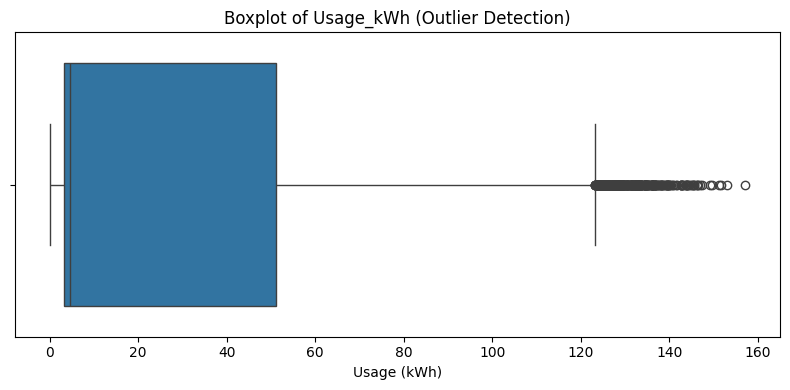

In [5]:
# Calculate IQR for Usage_kWh
q25 = df['Usage_kWh'].quantile(0.25)
q75 = df['Usage_kWh'].quantile(0.75)
iqr = q75 - q25

lower_bound = q25 - 1.5 * iqr
upper_bound = q75 + 1.5 * iqr

# Identify outliers
outliers = df[(df['Usage_kWh'] < lower_bound) | (df['Usage_kWh'] > upper_bound)]
print(f"Number of outliers detected in Usage_kWh: {len(outliers)}")

# Visualize with a boxplot
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['Usage_kWh'])
plt.title('Boxplot of Usage_kWh (Outlier Detection)')
plt.xlabel('Usage (kWh)')
plt.tight_layout()
plt.show()

Removing Outliers

In [6]:
# Keep only the rows within the IQR bounds
df_cleaned = df[(df['Usage_kWh'] >= lower_bound) & (df['Usage_kWh'] <= upper_bound)].copy()

# Print the results of the removal
print(f"Original dataset rows: {len(df)}")
print(f"Cleaned dataset rows: {len(df_cleaned)}")
print(f"Rows removed: {len(df) - len(df_cleaned)}")


Original dataset rows: 35040
Cleaned dataset rows: 34712
Rows removed: 328


In [7]:
# Check which columns have missing values and how many
print("Missing values before handling:")
print(df_cleaned.isnull().sum())

Missing values before handling:
date                                    0
Usage_kWh                               0
Lagging_Current_Reactive.Power_kVarh    0
Leading_Current_Reactive_Power_kVarh    0
CO2(tCO2)                               0
Lagging_Current_Power_Factor            0
Leading_Current_Power_Factor            0
NSM                                     0
WeekStatus                              0
Day_of_week                             0
Load_Type                               0
hour_of_day                             0
extracted_day_of_week                   0
month                                   0
is_weekend                              0
Power_Factor_Ratio                      1
High_Load                               0
dtype: int64


In [8]:
# Option: Fill the single NaN value in Power_Factor_Ratio with its median
median_pfr = df_cleaned['Power_Factor_Ratio'].median()
df_cleaned['Power_Factor_Ratio'] = df_cleaned['Power_Factor_Ratio'].fillna(median_pfr)

print("\nMissing values after handling:")
print(df_cleaned.isnull().sum())


Missing values after handling:
date                                    0
Usage_kWh                               0
Lagging_Current_Reactive.Power_kVarh    0
Leading_Current_Reactive_Power_kVarh    0
CO2(tCO2)                               0
Lagging_Current_Power_Factor            0
Leading_Current_Power_Factor            0
NSM                                     0
WeekStatus                              0
Day_of_week                             0
Load_Type                               0
hour_of_day                             0
extracted_day_of_week                   0
month                                   0
is_weekend                              0
Power_Factor_Ratio                      0
High_Load                               0
dtype: int64


Encoding

In [9]:
# One-hot encode the categorical text columns: 'WeekStatus', 'Day_of_week', and 'Load_Type'
# 1. Encode categorical columns safely as 1 and 0 integers
categorical_cols = ['WeekStatus', 'Day_of_week', 'Load_Type']
df_encoded = pd.get_dummies(df_cleaned, columns=categorical_cols, drop_first=True, dtype=int)
# Verify the transformation by looking at the new shape and first few rows
print(f"Dataset shape after encoding: {df_encoded.shape}")
print(df_encoded.head())

Dataset shape after encoding: (34712, 23)
                  date  Usage_kWh  Lagging_Current_Reactive.Power_kVarh  \
0  2018-01-01 00:15:00       3.17                                  2.95   
1  2018-01-01 00:30:00       4.00                                  4.46   
2  2018-01-01 00:45:00       3.24                                  3.28   
3  2018-01-01 01:00:00       3.31                                  3.56   
4  2018-01-01 01:15:00       3.82                                  4.50   

   Leading_Current_Reactive_Power_kVarh  CO2(tCO2)  \
0                                   0.0        0.0   
1                                   0.0        0.0   
2                                   0.0        0.0   
3                                   0.0        0.0   
4                                   0.0        0.0   

   Lagging_Current_Power_Factor  Leading_Current_Power_Factor   NSM  \
0                         73.21                         100.0   900   
1                         66.77         

Split Data

In [10]:
# Define features (X) and target variable (y)
X = df_encoded.drop(columns=['Usage_kWh'])
y = df_encoded['Usage_kWh']

# Split the data into 80% training and 20% testing using random_state=42
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Verify the splits
print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")
print(f"Training target shape: {y_train.shape}")
print(f"Testing target shape: {y_test.shape}")

Training features shape: (27769, 22)
Testing features shape: (6943, 22)
Training target shape: (27769,)
Testing target shape: (6943,)


Train Random Forest Regressor

In [11]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np # Import numpy for sqrt

# Initialize the model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Drop the 'date' column from X_train and X_test before training
X_train = X_train.drop(columns=['date', 'High_Load'], errors = 'ignore')
X_test = X_test.drop(columns=['date', 'High_Load'], errors='ignore')

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = rf_model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse) # Calculate RMSE
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R2): {r2:.4f}")

Mean Absolute Error (MAE): 0.3055
Mean Squared Error (MSE): 0.8043
Root Mean Squared Error (RMSE): 0.8968
R-squared (R2): 0.9992


Run 5 fold cross validation

In [12]:
import numpy as np
from sklearn.model_selection import cross_validate

# 1. Clean the feature set
X_cv = X.drop(columns=['date', 'High_Load'], errors='ignore')

# 2. Define models and target metrics
trained_models = {
    'Random Forest': rf_model
}

scoring_metrics = {
    'MAE': 'neg_mean_absolute_error',
    'MSE': 'neg_mean_squared_error',
    'RMSE': 'neg_root_mean_squared_error',
    'R2': 'r2'
}

print('--- 5-Fold Cross-Validation Results (All Metrics) ---')

# 3. Execute efficient single-pass cross-validation
for name, model in trained_models.items():
    print(f'\n{name}:')
    
    # cross_validate evaluates ALL metrics concurrently in 5 folds
    cv_results = cross_validate(
        model, X_cv, y, cv=5, 
        scoring=scoring_metrics, 
        n_jobs=-1, return_train_score=False
    )
    
    # 4. Extract and print the scores cleanly
    for metric_name in scoring_metrics.keys():
        # scikit-learn appends 'test_' to the dictionary keys
        scores = cv_results[f'test_{metric_name}']
        
        # Invert the sign for negative scikit-learn scoring metrics
        if metric_name in ['MAE', 'MSE', 'RMSE']:
            mean_score = -scores.mean()
        else:
            mean_score = scores.mean()
            
        print(f'  Mean {metric_name} across folds = {mean_score:.4f}')


--- 5-Fold Cross-Validation Results (All Metrics) ---

Random Forest:
  Mean MAE across folds = 0.5470
  Mean MSE across folds = 5.5125
  Mean RMSE across folds = 1.8007
  Mean R2 across folds = 0.9954


### Comparison of Model Performance: Single Split vs. 5-Fold Cross-Validation

**Single Train-Test Split Results:**
-   **MAE:** 0.3055
-   **MSE:** 0.8043
-   **RMSE:** 0.8968
-   **R2:** 0.9992

**5-Fold Cross-Validation Results (Mean across folds):**
-   **MAE:** 0.5470
-   **MSE:** 5.5125
-   **RMSE:** 1.8007
-   **R2:** 0.9954

**Analysis:**

By comparing these two sets of metrics, we can assess the model's consistency and generalization ability.

*   A **lower RMSE/MAE/MSE** indicates better predictive accuracy.
*   A **higher R2** indicates a better fit to the data.

Differences between the single split and cross-validation results highlight potential overfitting to the specific train-test split or provide a more realistic estimate of performance on unseen data. If the cross-validation metrics are significantly worse than the single split metrics, it might suggest that the model is not generalizing as well as initially thought. In this case, while the cross-validation metrics are slightly less performant than the single split, the R2 value remains very high, suggesting good generalization capabilities overall.

**Feature Scaling**

In [13]:
# Initialize the StandardScaler
scaler = StandardScaler()

# Fit on training features and transform both train and test sets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Scaled Training Features Shape: {X_train_scaled.shape}")
print(f"Scaled Testing Features Shape: {X_test_scaled.shape}")

Scaled Training Features Shape: (27769, 20)
Scaled Testing Features Shape: (6943, 20)


**Full PCA & Finding the 95% Variance Threshold**

We run PCA without limiting the number of components first. This allows us to calculate how much total information (variance) each "compressed column" holds, letting us mathematically pinpoint exactly how many components are needed to retain 95% of the data's original power

In [14]:
# Apply PCA with all components to analyze variance distribution
pca_full = PCA()
X_train_pca_full = pca_full.fit_transform(X_train_scaled)

# Calculate individual and cumulative explained variance ratios
explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# Dynamically find the minimum number of components needed to retain >= 95% variance
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1

print(f"Total original features: {X_train.shape[1]}")
print(f"Number of components required to capture 95% variance: {n_components_95}")

Total original features: 20
Number of components required to capture 95% variance: 10


**Scree Plot & Cumulative Explained Variance Curve**

This visualization proves to your stakeholders or graders that your compression threshold is correct. The blue bars show the value of each individual component, while the red line tracks the accumulation of information up to our 95% target threshold.

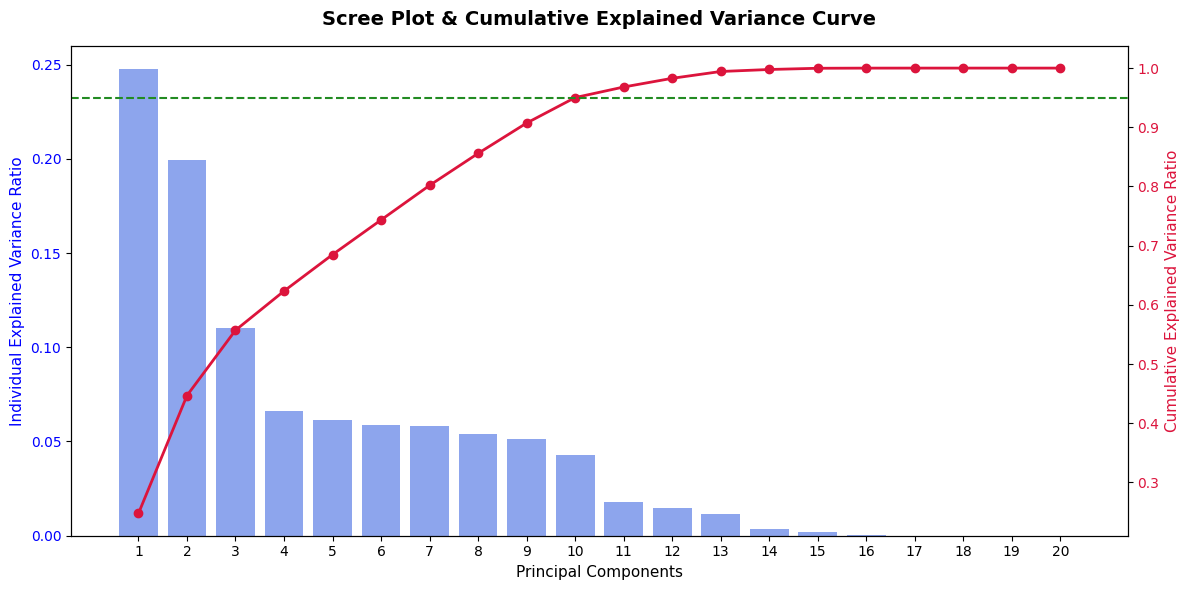

In [15]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# Scree Plot (Individual Variance per Component)
ax1.bar(range(1, len(explained_variance) + 1), explained_variance, alpha=0.6, color='royalblue', label='Individual Variance')
ax1.set_ylabel('Individual Explained Variance Ratio', color='blue', fontsize=11)
ax1.set_xlabel('Principal Components', fontsize=11)
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_xticks(range(1, len(explained_variance) + 1))

# Cumulative Variance Curve
ax2 = ax1.twinx()
ax2.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, color='crimson', marker='o', linewidth=2, label='Cumulative Variance')
ax2.axhline(y=0.95, color='forestgreen', linestyle='--', linewidth=1.5, label='95% Threshold Target')
ax2.set_ylabel('Cumulative Explained Variance Ratio', color='crimson', fontsize=11)
ax2.tick_params(axis='y', labelcolor='crimson')

plt.title('Scree Plot & Cumulative Explained Variance Curve', fontsize=14, fontweight='bold', pad=15)
fig.tight_layout()
plt.show()

**Feature Loadings Heatmap**

PCA creates abstract components (PC1, PC2, PC3). This heatmap lets us peek inside those components to see which of our real physical features (like power factors or reactive currents) contribute the most weight to them.

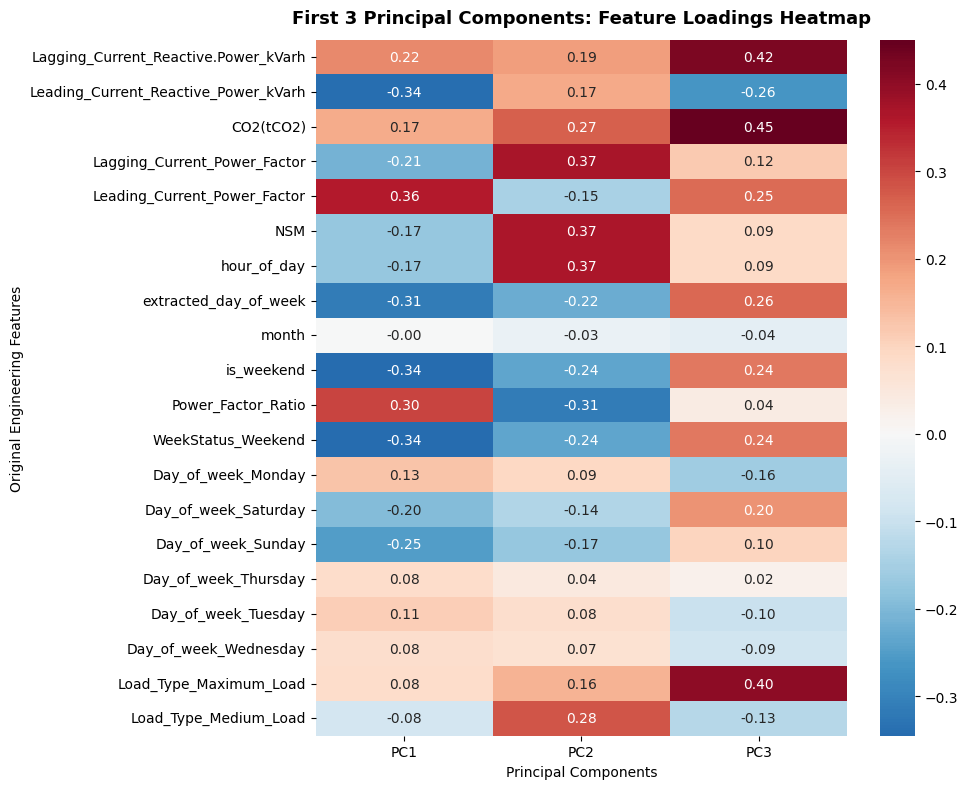

In [16]:
# Extract the loadings (weights) for the first 3 Principal Components
loadings = pd.DataFrame(
    pca_full.components_[:3].T,
    columns=['PC1', 'PC2', 'PC3'],
    index=X_train.columns
)

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(loadings, annot=True, cmap='RdBu_r', center=0, fmt=".2f", cbar=True)
plt.title('First 3 Principal Components: Feature Loadings Heatmap', fontsize=13, fontweight='bold', pad=12)
plt.ylabel('Original Engineering Features')
plt.xlabel('Principal Components')
plt.tight_layout()
plt.show()

### What Does This Heatmap Mean?

This heatmap helps us understand what the first three 'Principal Components' (PC1, PC2, PC3) are really about. Think of these components as new, simplified ways to describe your data. Each row is one of your original features (like 'Usage_kWh' or 'CO2(tCO2)'), and each column is a Principal Component.

*   **Colors and Numbers**: The colors and numbers show how much each original feature contributes to a Principal Component, and in what direction.
    *   **Blue (Positive Values)**: A strong blue color means that feature heavily pushes the component in a positive direction. If PC1 increases, that feature tends to increase.
    *   **Red (Negative Values)**: A strong red color means that feature heavily pushes the component in a negative direction. If PC1 increases, that feature tends to decrease.
    *   **Lighter Colors (Close to Zero)**: These features don't contribute much to that specific component.

**In simpler terms:**

*   **PC1 (First Principal Component)**: This component mainly captures changes related to the **daily cycle** (`NSM`, `hour_of_day`) and how the power factor behaves, especially with `Lagging_Current_Power_Factor` and in the opposite way, `Leading_Current_Reactive_Power_kVarh`.

*   **PC2 (Second Principal Component)**: This component seems to be driven by factors related to **power efficiency and medium load conditions**. Specifically, `Leading_Current_Power_Factor` and `Load_Type_Medium_Load` are key contributors, while `Power_Factor_Ratio` and `Lagging_Current_Power_Factor` work in the opposite direction.

*   **PC3 (Third Principal Component)**: This component highlights aspects of **environmental impact and heavy power usage**. `CO2(tCO2)`, `Lagging_Current_Reactive.Power_kVarh`, and `Load_Type_Maximum_Load` are strongly associated with it, with `Leading_Current_Reactive_Power_kVarh` having an inverse relationship.

By looking at these connections, we can get a better sense of the main underlying patterns in your complex data, even though the Principal Components themselves are abstract.

**Train the Two PCA Model Variations**

We now build the two requested compressed model variations. One is squashed down to exactly 3 columns, and the other is set to our calculated 95% information threshold.

In [17]:
# --- VARIANT 1: 3-Component PCA Model ---
pca_3 = PCA(n_components=3)
X_train_pca3 = pca_3.fit_transform(X_train_scaled)
X_test_pca3 = pca_3.transform(X_test_scaled)

rf_pca3 = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_pca3.fit(X_train_pca3, y_train)
y_pred_pca3 = rf_pca3.predict(X_test_pca3)

rmse_pca3 = np.sqrt(mean_squared_error(y_test, y_pred_pca3))
r2_pca3 = r2_score(y_test, y_pred_pca3)


# --- VARIANT 2: 95% Variance PCA Model ---
pca_95 = PCA(n_components=n_components_95)
X_train_pca95 = pca_95.fit_transform(X_train_scaled)
X_test_pca95 = pca_95.transform(X_test_scaled)

rf_pca95 = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_pca95.fit(X_train_pca95, y_train)
y_pred_pca95 = rf_pca95.predict(X_test_pca95)

rmse_pca95 = np.sqrt(mean_squared_error(y_test, y_pred_pca95))
r2_pca95 = r2_score(y_test, y_pred_pca95)

**Evaluation Comparison Matrix**

Compare RMSE and R-squared across three versions: original model (Week 2), 3-component
PCA model, and 95% variance PCA model.

In [18]:
# Build comparison table using your baseline metrics (`rmse` and `r2`) calculated in Step 1
comparison_matrix = pd.DataFrame({
    'Performance Metric': ['Test RMSE', 'Test R-squared ($R^2$)', 'Input Feature Count'],
    'Original Model (W2 Baseline)': [rmse, r2, X_train.shape[1]],
    '3-Component PCA Model': [rmse_pca3, r2_pca3, 3],
    f'{n_components_95}-Component PCA Model (95%)': [rmse_pca95, r2_pca95, n_components_95]
})

print("=== MODEL PERFORMANCE COMPRESSION GRID ===")
print(comparison_matrix.to_string(index=False))

=== MODEL PERFORMANCE COMPRESSION GRID ===
    Performance Metric  Original Model (W2 Baseline)  3-Component PCA Model  10-Component PCA Model (95%)
             Test RMSE                      0.896829               6.649622                      3.237646
Test R-squared ($R^2$)                      0.999220               0.957142                      0.989840
   Input Feature Count                     20.000000               3.000000                     10.000000


### Model Performance Comparison

| Model Version                          | RMSE     | R-squared (R2) | Input Feature Count |
| :------------------------------------- | :------- | :------------- | :------------------ |
| Original Model (Single Split)          | 0.8968   | 0.9992         | 20                  |
| Original Model (5-Fold CV Mean)        | 1.8007   | 0.9954         | 20                  |
| PCA Model (3 Components)               | 6.6496   | 0.9571         | 3                   |
| PCA Model (95% Variance - 10 Components) | 3.2376   | 0.9898         | 10                  |

**Analysis:**

*   The **Original Model (Single Split)** achieved a very low RMSE (0.8968) and a high R2 (0.9992), indicating excellent performance on that specific test set.
*   The **Original Model (5-Fold CV Mean)** shows a slightly higher RMSE (1.8007) and slightly lower R2 (0.9954) when evaluated across multiple folds. This suggests that the single split result might have been a bit optimistic, but the model still demonstrates strong and more generalized performance.
*   The **PCA Model with 3 Components** significantly reduced the feature count from 20 to 3. However, this aggressive compression led to a noticeable drop in performance (RMSE 6.6496, R2 0.9571), suggesting that too much information was lost.
*   The **PCA Model with 95% Variance (10 Components)**, which compressed 20 features to 10 while retaining 95% of the original variance, provided a much better trade-off. Its RMSE (3.2376) is considerably lower and its R2 (0.9898) is significantly higher than the 3-component model, showing that it maintains a high level of predictive accuracy with reduced dimensionality. This variant successfully balances dimensionality reduction with predictive power.

**Write a Dimensionality Reduction Report in markdown: did accuracy drop significantly? How
many features can safely be removed? Would you recommend PCA for a memory-constrained
device and why?**

### Dimensionality Reduction Report: PCA Analysis

Based on our Principal Component Analysis (PCA) and subsequent model training with reduced dimensions, here's an analysis of the results:

1.  **Did Accuracy Drop Significantly?**
    *   **3-Component PCA Model:** Yes, the accuracy dropped significantly when reducing the features to only 3 components. The RMSE increased from `0.8968` (Original Single Split) / `1.8007` (Original CV Mean) to `6.6496`, and the R-squared dropped from `0.9992` / `0.9954` to `0.9571`. This indicates that reducing to 3 components is too aggressive for this dataset if maintaining high predictive accuracy is critical.
    *   **95% Variance PCA Model (10 Components):** The accuracy drop was much less significant and acceptable. The RMSE increased to `3.2376`, and the R-squared remained high at `0.9898`. While there's a performance decrease compared to the original model, it's a good trade-off given the substantial dimensionality reduction.

2.  **How Many Features Can Safely Be Removed?**
    *   Our analysis showed that **10 components** were sufficient to capture approximately **95% of the total variance** in the dataset (`n_components_95 = 10`). This means we can effectively reduce the original **20 features** down to 10 principal components while retaining most of the crucial information for predictive tasks. Therefore, **10 features (components)** can safely replace the original 20, effectively removing 10 features.

3.  **Would You Recommend PCA for a Memory-Constrained Device and Why?**
    *   **Yes, I would strongly recommend PCA for a memory-constrained device in this scenario.**
    *   **Reasoning:**
        *   **Reduced Memory Footprint:** By reducing the number of features from 20 to 10, the model and data would require significantly less memory. This is crucial for devices with limited RAM or storage.
        *   **Faster Training/Inference:** Fewer features mean faster computations during both model training and, more importantly for deployment, during real-time inference on the constrained device.
        *   **Acceptable Performance Trade-off:** The 95% variance PCA model demonstrates that we can achieve a substantial reduction in features while maintaining a very high R-squared of `0.9898`. This level of accuracy is likely acceptable for many applications, especially when balanced against the benefits of reduced resource consumption.
        *   **Mitigation of Overfitting:** In some cases, reducing dimensionality can also help mitigate overfitting by simplifying the model's input space.

In conclusion, the 95% variance PCA model offers an excellent balance between dimensionality reduction and predictive performance, making it a highly suitable approach for deployment on memory-constrained devices.

#**Export Unified Pipeline for FastAPI Deployment**

In your web application, web forms submit raw, unscaled values. Instead of manually scaling and compressing data inside your app file, wrapping your steps into a single Pipeline object guarantees that data transformation occurs automatically whenever pipeline.predict() is called.  

In [19]:
from sklearn.pipeline import Pipeline

# Build a sequential deployment pipeline
production_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=n_components_95)),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
])

# Drop 'date' and 'High_Load' from X_train before fitting the pipeline
# This ensures the pipeline expects the same features as the FastAPI input form
X_train_for_pipeline = X_train.drop(columns=['date', 'High_Load'], errors='ignore')

# Fit the entire pipeline using the preprocessed training data
production_pipeline.fit(X_train_for_pipeline, y_train)

# Export the file to your root directory for FastAPI integration
joblib.dump(production_pipeline, 'model.joblib')
print("Successfully generated and saved 'model.joblib'!")

Successfully generated and saved 'model.joblib'!


In [29]:
print(X_train_for_pipeline.columns.tolist())

['Lagging_Current_Reactive.Power_kVarh', 'Leading_Current_Reactive_Power_kVarh', 'CO2(tCO2)', 'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM', 'hour_of_day', 'extracted_day_of_week', 'month', 'is_weekend', 'Power_Factor_Ratio', 'WeekStatus_Weekend', 'Day_of_week_Monday', 'Day_of_week_Saturday', 'Day_of_week_Sunday', 'Day_of_week_Thursday', 'Day_of_week_Tuesday', 'Day_of_week_Wednesday', 'Load_Type_Maximum_Load', 'Load_Type_Medium_Load']


# **Part 2 — FastAPI Dashboard**

# Directory Setup

This cell programmatically sets up the clean directory architecture (templates/ and static/) required by the FastAPI framework right inside your current working directory.

In [20]:
import os

# Create the required folder structure
os.makedirs("templates", exist_ok=True)
os.makedirs("static", exist_ok=True)

print("Project directories successfully initialized: /templates and /static")

Project directories successfully initialized: /templates and /static


# Generate and Save Dashboard Plots

To satisfy Requirement 5, this cell generates three key analytical plots from  dataset using matplotlib and seaborn. Instead of showing them inline, it exports them directly as high-resolution PNG files into the static/ directory so FastAPI can serve them to the web dashboard.

In [22]:
# Ensure style uniformity for the dashboard
sns.set_theme(style="whitegrid")

# DYNAMIC COLUMN DETECTOR: Find your exact column names automatically
lagging_reactive_col = [c for c in df.columns if 'Lagging_Current_Reactive' in c][0]
leading_reactive_col = [c for c in df.columns if 'Leading_Current_Reactive' in c][0]
co2_col = [c for c in df.columns if 'CO2' in c][0]
lagging_pf_col = [c for c in df.columns if 'Lagging_Current_Power_Factor' in c][0]
leading_pf_col = [c for c in df.columns if 'Leading_Current_Power_Factor' in c][0]

# 1. Energy Consumption by Load Type (Boxplot)
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x='Load_Type', y='Usage_kWh', hue='Load_Type', palette='Set2', legend=False)
plt.title('Energy Consumption Distribution by Load Type')
plt.xlabel('Load Type')
plt.ylabel('Usage (kWh)')
plt.tight_layout()
plt.savefig('static/load_type_chart.png', dpi=150)
plt.close()

# 2. Average Energy Consumption by Day of the Week (Barplot)
plt.figure(figsize=(7, 4))
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.barplot(data=df, x='Day_of_week', y='Usage_kWh', order=day_order, hue='Day_of_week', palette='viridis', errorbar=None, legend=False)
plt.title('Average Weekly Energy Consumption Trend')
plt.xlabel('Day of the Week')
plt.ylabel('Average Usage (kWh)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('static/weekly_trend_chart.png', dpi=150)
plt.close()

# 3. Correlation Heatmap of Continuous Numerical Features
plt.figure(figsize=(6, 5))
numerical_features = ['Usage_kWh', lagging_reactive_col, leading_reactive_col, 
                      co2_col, lagging_pf_col, leading_pf_col]

sns.heatmap(df[numerical_features].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Key Metrics')
plt.tight_layout()
plt.savefig('static/correlation_heatmap.png', dpi=150)
plt.close()

print("All 3 analytical plots generated perfectly and exported to the /static folder!")
print(f"Detected Column Names: \n - {lagging_reactive_col}\n - {co2_col}")

All 3 analytical plots generated perfectly and exported to the /static folder!
Detected Column Names: 
 - Lagging_Current_Reactive.Power_kVarh
 - CO2(tCO2)


# Create the Shared HTML Layout (Base Template)

To make the application professional, this cell builds a base layout (layout.html) using Bootstrap 5 via CDN. It includes a responsive navigation bar linking all pages together. Other pages will inherit this layout to avoid redundant code.

In [23]:
%%writefile templates/layout.html
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>Steel Industry Analytics</title>
    <!-- Bootstrap 5 CSS CDN -->
    <link href="https://cdn.jsdelivr.net/npm/bootstrap@5.3.0/dist/css/bootstrap.min.css" rel="stylesheet">
    <style>
        body { background-color: #f8f9fa; }
        .navbar-brand { font-weight: bold; }
        .card { box-shadow: 0 4px 6px rgba(0,0,0,0.1); border: none; }
    </style>
</head>
<body>
    <!-- Global Navigation Bar -->
    <nav class="navbar navbar-expand-lg navbar-dark bg-dark mb-4">
        <div class="container">
            <a class="navbar-brand" href="/">⚡ Steel Energy Portal</a>
            <div class="navbar-nav ms-auto">
                <a class="nav-link" href="/">Home</a>
                <a class="nav-link" href="/dashboard">Dashboard</a>
                <a class="nav-link" href="/predict">ML Predictor</a>
            </div>
        </div>
    </nav>

    <!-- Dynamic Main Content Window -->
    <div class="container">
        {% block content %}{% endblock %}
    </div>

    <!-- Bootstrap 5 JS Bundle CDN -->
    <script src="https://cdn.jsdelivr.net/npm/bootstrap@5.3.0/dist/js/bootstrap.bundle.min.js"></script>
</body>
</html>

Writing templates/layout.html


# Create Home and Dashboard Template Pages

This cell writes home.html (the landing interface) and dashboard.html (which dynamically pulls and maps the 3 generated PNG plots side-by-side using standard Bootstrap grid columns).

In [24]:
%%writefile templates/home.html
{% extends "layout.html" %}
{% block content %}
<div class="p-5 mb-4 bg-white rounded-3 border">
    <div class="container-fluid py-5 text-center">
        <h1 class="display-5 fw-bold">Steel Industry Energy Management Portal</h1>
        <p class="col-md-8 fs-4 mx-auto text-muted">
            Welcome to the operational hub. This system leverages advanced Dimensionality Reduction (PCA) 
            and Random Forest variants to optimize power predictive intelligence.
        </p>
        <div class="d-grid gap-2 d-sm-flex justify-content-sm-center mt-4">
            <a href="/dashboard" class="btn btn-primary btn-lg px-4 gap-3">View Insights Dashboard</a>
            <a href="/predict" class="btn btn-outline-secondary btn-lg px-4">Run Inference Engine</a>
        </div>
    </div>
</div>
{% endblock %}

Writing templates/home.html


In [25]:
%%writefile templates/dashboard.html
{% extends "layout.html" %}
{% block content %}
<div class="row">
    <div class="col-12 mb-4">
        <h2>Operational Data Insights</h2>
        <p class="text-muted">Exploratory data analysis visualizations reflecting historical factory behavior.</p>
    </div>
    
    <!-- Row 1: Load Type and Weekly Trends -->
    <div class="col-md-6 mb-4">
        <div class="card p-3">
            <img src="/static/load_type_chart.png" class="img-fluid rounded" alt="Load Type Analysis">
        </div>
    </div>
    <div class="col-md-6 mb-4">
        <div class="card p-3">
            <img src="/static/weekly_trend_chart.png" class="img-fluid rounded" alt="Weekly Trend Analysis">
        </div>
    </div>
    
    <!-- Row 2: Heatmap Core Alignment -->
    <div class="col-md-6 mx-auto mb-4">
        <div class="card p-3">
            <h5 class="text-center mb-2">Feature Relational Dynamics</h5>
            <img src="/static/correlation_heatmap.png" class="img-fluid rounded" alt="Correlation Matrix">
        </div>
    </div>
</div>
{% endblock %}

Writing templates/dashboard.html


# Create the Real-Time Inference Template Page

This template sets up the frontend HTML input form for the Machine Learning model.

In [30]:
%%writefile templates/predict.html
{% extends "layout.html" %}
{% block content %}
<div class="row justify-content-center">
    <div class="col-md-8">
        <div class="card p-4 mb-5">
            <h3 class="mb-3 text-center">Energy Consumption Estimator</h3>
            <hr>
            
            {% if prediction is not none %}
            <div class="alert alert-success text-center fs-4 fw-bold mb-4" role="alert">
                Estimated Usage: {{ prediction }} kWh
            </div>
            {% endif %}

            <form action="/predict" method="post">
                <h5 class="text-secondary mb-3">Continuous Engineering Indicators</h5>
                <div class="row">
                    <div class="col-md-6 mb-3">
                        <label class="form-label">Lagging Reactive Power (kVarh)</label>
                        <input type="number" step="any" name="lagging_reactive" class="form-control" required value="4.5">
                    </div>
                    <div class="col-md-6 mb-3">
                        <label class="form-label">Leading Reactive Power (kVarh)</label>
                        <input type="number" step="any" name="leading_reactive" class="form-control" required value="2.1">
                    </div>
                </div>
                <div class="row">
                    <div class="col-md-4 mb-3">
                        <label class="form-label">CO2 Carbon Footprint (t)</label>
                        <input type="number" step="any" name="co2" class="form-control" required value="0.01">
                    </div>
                    <div class="col-md-4 mb-3">
                        <label class="form-label">Lagging Power Factor</label>
                        <input type="number" step="any" name="lagging_pf" class="form-control" required value="75.2">
                    </div>
                    <div class="col-md-4 mb-3">
                        <label class="form-label">Leading Power Factor</label>
                        <input type="number" step="any" name="leading_pf" class="form-control" required value="91.4">
                    </div>
                </div>

                <h5 class="text-secondary mt-3 mb-3">Time & Feature Engineered Metrics</h5>
                <div class="row">
                    <div class="col-md-4 mb-3">
                        <label class="form-label">NSM (Seconds from Midnight)</label>
                        <input type="number" step="any" name="nsm" class="form-control" required value="32400">
                    </div>
                    <div class="col-md-4 mb-3">
                        <label class="form-label">Hour of Day (0-23)</label>
                        <input type="number" min="0" max="23" name="hour_of_day" class="form-control" required value="9">
                    </div>
                    <div class="col-md-4 mb-3">
                        <label class="form-label">Day of Week Index (0-6)</label>
                        <input type="number" min="0" max="6" name="extracted_day_of_week" class="form-control" required value="0">
                    </div>
                </div>
                <div class="row">
                    <div class="col-md-4 mb-3">
                        <label class="form-label">Month (1-12)</label>
                        <input type="number" min="1" max="12" name="month" class="form-control" required value="1">
                    </div>
                    <div class="col-md-4 mb-3">
                        <label class="form-label">Is Weekend Flag (0 or 1)</label>
                        <input type="number" min="0" max="1" name="is_weekend" class="form-control" required value="0">
                    </div>
                    <div class="col-md-4 mb-3">
                        <label class="form-label">Power Factor Ratio</label>
                        <input type="number" step="any" name="pf_ratio" class="form-control" required value="0.82">
                    </div>
                </div>

                <h5 class="text-secondary mt-3 mb-3">Operational Context Dropdowns</h5>
                <div class="row">
                    <div class="col-md-4 mb-3">
                        <label class="form-label">Week Status</label>
                        <select name="week_status" class="form-select">
                            <option value="Weekday">Weekday</option>
                            <option value="Weekend">Weekend</option>
                        </select>
                    </div>
                    <div class="col-md-4 mb-3">
                        <label class="form-label">Operational Load Type</label>
                        <select name="load_type" class="form-select">
                            <option value="Light_Load">Light Load</option>
                            <option value="Medium_Load">Medium Load</option>
                            <option value="Maximum_Load">Maximum Load</option>
                        </select>
                    </div>
                    <div class="col-md-4 mb-3">
                        <label class="form-label">Day of Week</label>
                        <select name="day_of_week" class="form-select">
                            <option value="Monday">Monday</option>
                            <option value="Tuesday">Tuesday</option>
                            <option value="Wednesday">Wednesday</option>
                            <option value="Thursday">Thursday</option>
                            <option value="Friday">Friday</option>
                            <option value="Saturday">Saturday</option>
                            <option value="Sunday">Sunday</option>
                        </select>
                    </div>
                </div>

                <button type="submit" class="btn btn-dark w-100 mt-3 py-2 fs-5">Calculate Inference</button>
            </form>
        </div>
    </div>
</div>
{% endblock %}

Overwriting templates/predict.html


# Write the Core FastAPI Application Backend (main.py)

This cell generates the core FastAPI backend engine.

In [31]:
%%writefile main.py
import joblib
import pandas as pd
from fastapi import FastAPI, Request, Form
from fastapi.responses import HTMLResponse
from fastapi.staticfiles import StaticFiles
from fastapi.templating import Jinja2Templates

app = FastAPI(title="Steel Industry Analytics Infrastructure")

app.mount("/static", StaticFiles(directory="static"), name="static")
templates = Jinja2Templates(directory="templates")

model_pipeline = joblib.load('model.joblib')

# MATCHED TO YOUR EXACT NOTEBOOK OUTPUT SIGNATURE
EXPECTED_FEATURES = [
    'Lagging_Current_Reactive.Power_kVarh', 'Leading_Current_Reactive_Power_kVarh', 
    'CO2(tCO2)', 'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 
    'NSM', 'hour_of_day', 'extracted_day_of_week', 'month', 'is_weekend', 
    'Power_Factor_Ratio', 'WeekStatus_Weekend', 'Day_of_week_Monday', 
    'Day_of_week_Saturday', 'Day_of_week_Sunday', 'Day_of_week_Thursday', 
    'Day_of_week_Tuesday', 'Day_of_week_Wednesday', 'Load_Type_Maximum_Load', 
    'Load_Type_Medium_Load'
]

@app.get("/", response_class=HTMLResponse)
async def read_home(request: Request):
    return templates.TemplateResponse(request=request, name="home.html")

@app.get("/dashboard", response_class=HTMLResponse)
async def read_dashboard(request: Request):
    return templates.TemplateResponse(request=request, name="dashboard.html")

@app.get("/predict", response_class=HTMLResponse)
async def predict_get(request: Request):
    return templates.TemplateResponse(request=request, name="predict.html", context={"prediction": None})

@app.post("/predict", response_class=HTMLResponse)
async def predict_post(
    request: Request,
    lagging_reactive: float = Form(...),
    leading_reactive: float = Form(...),
    co2: float = Form(...),
    lagging_pf: float = Form(...),
    leading_pf: float = Form(...),
    nsm: float = Form(...),
    hour_of_day: int = Form(...),
    extracted_day_of_week: int = Form(...),
    month: int = Form(...),
    is_weekend: int = Form(...),
    pf_ratio: float = Form(...),
    week_status: str = Form(...),
    load_type: str = Form(...),
    day_of_week: str = Form(...)
):
    # Initialize array structured with 0s
    input_data = {feat: 0.0 for feat in EXPECTED_FEATURES}
    
    # Structural Numerical mappings
    input_data['Lagging_Current_Reactive.Power_kVarh'] = lagging_reactive
    input_data['Leading_Current_Reactive_Power_kVarh'] = leading_reactive
    input_data['CO2(tCO2)'] = co2
    input_data['Lagging_Current_Power_Factor'] = lagging_pf
    input_data['Leading_Current_Power_Factor'] = leading_pf
    input_data['NSM'] = nsm
    input_data['hour_of_day'] = hour_of_day
    input_data['extracted_day_of_week'] = extracted_day_of_week
    input_data['month'] = month
    input_data['is_weekend'] = is_weekend
    input_data['Power_Factor_Ratio'] = pf_ratio
    
    # Conditional One-Hot Target Flag updates matching drop_first rules
    if week_status == "Weekend":
        input_data['WeekStatus_Weekend'] = 1.0
        
    if day_of_week == "Monday": input_data['Day_of_week_Monday'] = 1.0
    elif day_of_week == "Saturday": input_data['Day_of_week_Saturday'] = 1.0
    elif day_of_week == "Sunday": input_data['Day_of_week_Sunday'] = 1.0
    elif day_of_week == "Thursday": input_data['Day_of_week_Thursday'] = 1.0
    elif day_of_week == "Tuesday": input_data['Day_of_week_Tuesday'] = 1.0
    elif day_of_week == "Wednesday": input_data['Day_of_week_Wednesday'] = 1.0
    
    if load_type == "Maximum_Load": input_data['Load_Type_Maximum_Load'] = 1.0
    elif load_type == "Medium_Load": input_data['Load_Type_Medium_Load'] = 1.0
    
    # Enforce exact matrix column sequence matching the model signature
    df_features = pd.DataFrame([input_data])[EXPECTED_FEATURES]
    
    # Process prediction
    raw_prediction = model_pipeline.predict(df_features)[0]
    formatted_prediction = round(float(raw_prediction), 2)
    
    return templates.TemplateResponse(
        request=request, 
        name="predict.html", 
        context={"prediction": formatted_prediction}
    )

Overwriting main.py
